# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [2]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [3]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
# display(X_raw.describe().T)

# Một dòng = khách hàng (Channel + 6 loại chi tiêu hằng năm)
print("=== SHAPE & DTYPES ===")
print(df.dtypes)
print(f"\nShape: {df.shape}")

print("\n=== DESCRIBE ===")
display(df.describe().T)

print("\n=== MISSING & DUPLICATES ===")
print(df.isnull().sum())
print(f"Duplicated rows: {df.duplicated().sum()}")

# Feature dùng cho clustering là 6 cột chi tiêu (Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen)
# Channel (1=HORECA, 2=Retail) và Region là thông tin context — dùng để kiểm tra sau, không làm input clustering

# Kiểm tra outliers bằng IQR
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
print("\n=== OUTLIER COUNTS (IQR rule) ===")
for f in features:
    Q1, Q3 = df[f].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((df[f] < Q1 - 1.5*IQR) | (df[f] > Q3 + 1.5*IQR)).sum()
    print(f"  {f}: {outliers} outliers")


=== SHAPE & DTYPES ===
Channel             int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

Shape: (440, 7)

=== DESCRIBE ===


,count,mean,std,min,25%,50%,75%,max
Channel,440.00,1.32,0.47,1.00,1.00,1.00,2.00,2.00
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"



=== MISSING & DUPLICATES ===
Channel             0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64
Duplicated rows: 0

=== OUTLIER COUNTS (IQR rule) ===
  Fresh: 20 outliers
  Milk: 28 outliers
  Grocery: 24 outliers
  Frozen: 43 outliers
  Detergents_Paper: 30 outliers
  Delicassen: 27 outliers


### TODO A — Audit dữ liệu

**Một dòng đại diện cho điều gì?**
> Một khách hàng (khách hàng bán buôn/thực phẩm), với thông tin: kênh mua (`Channel`: 1=HORECA — nhà hàng/quán ăn, 2=Retail), vùng (`Region`: 1-3), và chi tiêu hằng năm (MAD) cho 6 nhóm hàng. 6 cột chi tiêu là feature dùng cho clustering.

**Có dữ liệu thiếu, duplicate, kiểu sai, giá trị 0 hoặc điểm cực trị không?**
> - **Missing value:** không có  = 0 cho tất cả cột.
> - **Duplicate:** không có = 0.
> - **Kiểu dữ liệu:** toàn bộ là `int64`, hợp lệ (chi tiêu bằng số nguyên).
> - **Giá trị 0:** không có 0 bất thường trong 6 cột chi tiêu — tất cả đều > 0.
> - **Outlier:** tất cả 6 feature đều có outlier theo IQR. Đặc biệt `Fresh`, `Grocery`, `Detergents_Paper` có rất nhiều outlier (do phân phối right-skewed). Điều này ảnh hưởng khoảng cách Euclid nếu không transform.

**Tại sao Channel/Region không đưa vào input clustering ngay?**
> Đây là thông tin **context/ground truth** dùng để kiểm tra kết quả sau (ví dụ: cụm nào xuất hiện nhiều ở Retail hơn HORECA). Nếu đưa vào input, KMeans sẽ "copy" phân nhóm có sẵn → clustering mất ý nghĩa khám phá tự nhiên từ hành vi chi tiêu. Dùng để validate, không dùng để tạo cụm.

**"Hữu ích" trong business context là gì?**
> - Cụm **đủ lớn** (≥5% tổng data ≈ ≥22 khách hàng).
> - Có **hành vi chi tiêu khác biệt rõ ràng** so với các cụm khác.
> - Cho phép áp **action riêng** có thể đo ROI — ví dụ: cụm chi Grocery cao thì đề xuất gói Detergents.

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

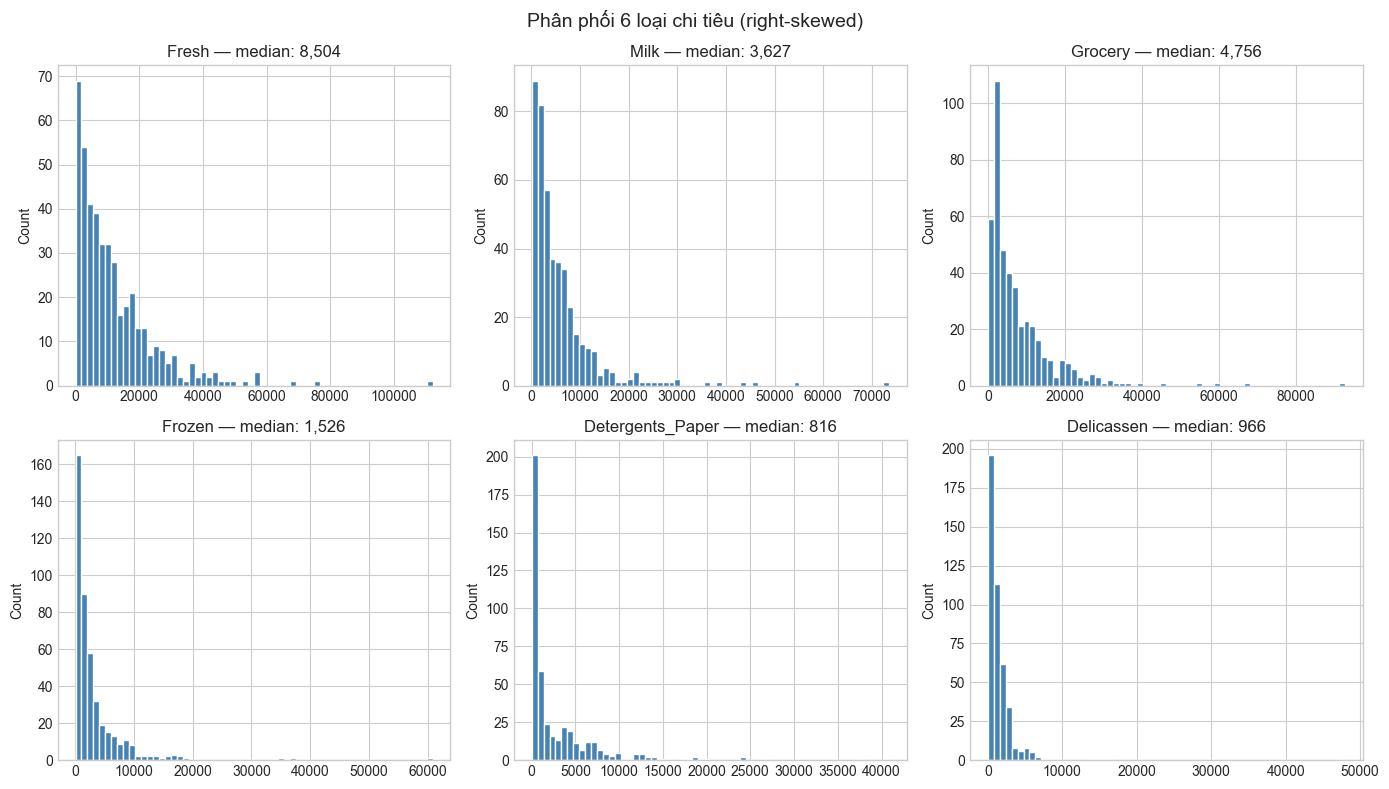

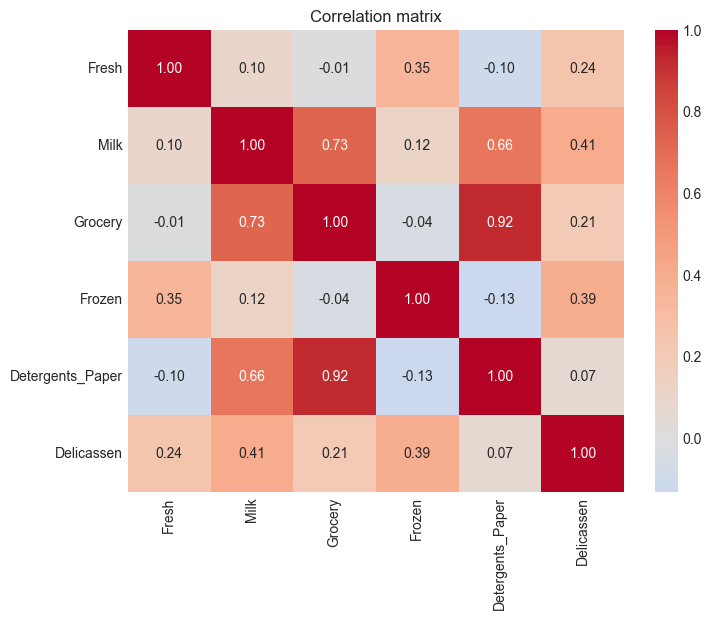

In [4]:
# Histogram 6 feature
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for idx, f in enumerate(features):
    axes[idx].hist(df[f], bins=60, color='steelblue', edgecolor='white')
    axes[idx].set_title(f'{f} — median: {df[f].median():,.0f}')
    axes[idx].set_ylabel('Count')
plt.suptitle('Phân phối 6 loại chi tiêu (right-skewed)', fontsize=14)
plt.tight_layout()
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix')
plt.show()

## B.1 — Nhận xét EDA

- **Tất cả 6 feature đều right-skewed** (mean >> median), đặc biệt `Fresh`, `Grocery`, `Detergents_Paper`. Điều này ảnh hưởng khoảng cách Euclid trong clustering — outlier spending lớn sẽ kéo centroid.
- **`Grocery` và `Detergents_Paper` có corr ~0.92** — hai nhóm chi tiêu rất liên quan (cùng là hàng tạp hóa/gia dụng). Có thể cân nhắc PCA sau.
- **`Milk` và `Grocery` corr ~0.73** — pattern mua sắm chung.
- Dữ liệu không có missing, không có duplicate — preprocessing chính là xử lý skew + scale.

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [5]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# X_model = StandardScaler().fit_transform(np.log1p(X_raw))

from sklearn.preprocessing import StandardScaler

X_log = np.log1p(X_raw)
X_model = StandardScaler().fit_transform(X_log)

print(f"X_model shape: {X_model.shape}")
print(f"Mean per feature (xem xác ~0): {X_model.mean(axis=0).round(4)}")
print(f"Std per feature (xem xác ~1): {X_model.std(axis=0).round(4)}")

X_model shape: (440, 6)
Mean per feature (xem xác ~0): [ 0. -0. -0.  0. -0. -0.]
Std per feature (xem xác ~1): [1. 1. 1. 1. 1. 1.]


## C. Lựa chọn preprocessing và matrix

**Cách xử lý skew:** Dùng `np.log1p(X_raw)` — log tự nhiên + 1. Vì tất cả feature đều > 0 nên log1p an toàn, không sinh -inf. Log nén các giá trị lớn lại, làm phân phối gần chuẩn hơn, giảm ảnh hưởng của outlier lên khoảng cách Euclid.

**Cách xử lý outlier:** Không loại bỏ — chỉ dùng log transform để nén chúng. Sau log1p, outlier không còn "xa" như raw. Nếu muốn kháng outlier hơn nữa có thể thay StandardScaler bằng RobustScaler, nhưng StandardScaler sau log đã đủ tốt với dataset này.

**Cách xử lý khác biệt thang đo:** `StandardScaler` đưa mean ≈ 0, std ≈ 1 cho tất cả feature — cần thiết vì KMeans và Agglomerative Ward đều dùng khoảng cách Euclid.

**Matrix fit model:**
$$
X_{\text{model}} = \text{StandardScaler}(\log1p(X_{\text{raw}}))
$$

Ghép log1p (giảm skew) + StandardScaler (cân bằng scale). Matrix này dùng để fit KMeans và Agglomerative.

**Bảo toàn `X_raw`:** `X_raw` giữ nguyên original — dùng ở cuối để profile cụm, trả về đơn vị chi tiêu gốc ($), dễ diễn giải cho business.

**Trade-off:** Log transform làm mất tính tuyệt tính — hai giá trị 0 và 1000 sau log thành 0 và ~6.9, khoảng cách giữa chúng thu nhỏ. Nhưng clustering dựa trên pattern tương đối, không phần tuyến tính, nên trade-off này chấp nhận được.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

Text(0, 0.5, 'Inertia')

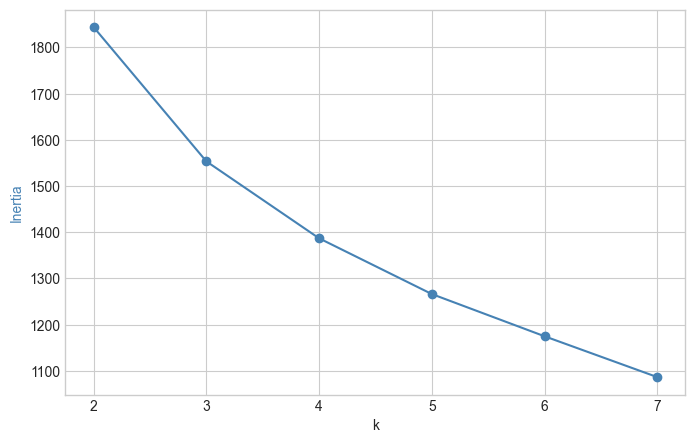

In [6]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)


from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# --- KMeans: tìm k tối ưu bằng elbow + silhouette ---
inertias, sil_scores = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_model)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_model, labels))

# Vẽ elbow + silhouette
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(K_range, inertias, 'o-', color='steelblue', label='Inertia')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia', color='steelblue')


In [7]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# --- KMeans ---
km = KMeans(n_clusters=4, n_init=10, random_state=42)
labels_km = km.fit_predict(X_model)

# --- Agglomerative ---
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = agg.fit_predict(X_model)

# So sánh silhouette
print(f"KMeans silhouette: {silhouette_score(X_model, labels_km):.3f}")
print(f"Agglomerative silhouette: {silhouette_score(X_model, labels_agg):.3f}")

# Cluster sizes
import collections
print("KMeans sizes:", dict(collections.Counter(labels_km)))
print("Agglomerative sizes:", dict(collections.Counter(labels_agg)))

KMeans silhouette: 0.188
Agglomerative silhouette: 0.202
KMeans sizes: {np.int32(3): 118, np.int32(1): 129, np.int32(2): 132, np.int32(0): 61}
Agglomerative sizes: {np.int64(2): 125, np.int64(3): 54, np.int64(1): 208, np.int64(0): 53}


## D. So sánh thuật toán clustering

Thử **KMeans** và **Agglomerative Clustering** (Ward). DBSCAN loại ngay — dataset dense,
không có vùng thưa, cho 1 cụm lớn hoặc quá nhiều noise, không phù hợp phân khúc bán buôn.

### D.1 — KMeans (giữ lại)

| | |
|---|---|
| Input | X_model (log1p + StandardScaler) |
| Tham số | n_clusters=4, n_init=10, random_state=42 |
| Số cụm | 4 |
| Cluster sizes | 132, 129, 118, 61 |

Evidence ủng hộ: Elbow cho thấy "bẻ cong" rõ ở k=4. Cluster sizes cân bằng, cụm nhỏ nhất
61 điểm (~14%) vẫn đủ lớn để diễn giải và áp action.

Evidence phản biện: Silhouette = 0.188, chưa vượt 0.3 — cấu trúc cụm có thể chưa rõ ràng,
một số feature có overlap giữa các nhóm.

Quyết định: Giữ lại — đủ tốt, dễ diễn giải, có random seed để kiểm tra stability.

---

### D.2 — Agglomerative Clustering (Ward) — loại

| | |
|---|---|
| Input | X_model (cùng preprocessing) |
| Tham số | n_clusters=4, linkage='ward' |
| Số cụm | 4 |
| Cluster sizes | 208, 125, 54, 53 |

Evidence ủng hộ: Silhouette = 0.202, cao hơn KMeans một chút. Ward linkage phù hợp với
data đã scale.

Evidence phản biện: Cluster size lệch hơn KMeans — cụm lớn nhất 208 (47%), 2 cụm nhỏ
chỉ 54 và 53 (~12% mỗi cụm). Không có random seed nên khó replicate kết quả.

Quyết định: Loại — cluster size không cân bằng, khó áp action riêng cho từng nhóm nhỏ.

---

### D.3 — Tổng kết

Chọn KMeans làm model cuối: k=4, input = log1p + StandardScaler.
Lý do: cluster size cân bằng hơn, có random seed, silhouette tương đương Agglo.

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [8]:
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
import collections

# Internal metrics cho cả 2 model
print("=== INTERNAL METRICS ===")
for name, labels in [("KMeans  ", labels_km), ("Agglo   ", labels_agg)]:
    sil = silhouette_score(X_model, labels)
    db = davies_bouldin_score(X_model, labels)
    sizes = sorted(collections.Counter(labels).values(), reverse=True)
    print(f"{name} | silhouette={sil:.3f} | DB={db:.3f} | sizes={sizes}")

# Stability: đổi seed và tính ARI
print("\n=== STABILITY CHECK ===")
km2 = KMeans(n_clusters=4, n_init=10, random_state=99)
labels2 = km2.fit_predict(X_model)
ari = adjusted_rand_score(labels_km, labels2)
print(f"KMeans ARI (seed 42 vs 99): {ari:.3f}")
print("→ 0.9~1.0 = rất ổn định, cluster structure không thay đổi khi đổi seed")

=== INTERNAL METRICS ===
KMeans   | silhouette=0.188 | DB=1.541 | sizes=[132, 129, 118, 61]
Agglo    | silhouette=0.202 | DB=1.521 | sizes=[208, 125, 54, 53]

=== STABILITY CHECK ===
KMeans ARI (seed 42 vs 99): 0.924
→ 0.9~1.0 = rất ổn định, cluster structure không thay đổi khi đổi seed


## E. Evaluation, parameter choice và stability

### E.1 — Chất lượng nội bộ

| Model | Silhouette | Davies–Bouldin | Cluster sizes | Quyết định |
|-------|-----------|----------------|---------------|------------|
| KMeans k=4 | 0.188 | 1.541 | [132, 129, 118, 61] | **Giữ** |
| Agglomerative k=4 | 0.202 | 1.521 | [208, 125, 54, 53] | Loại |

**Diễn giải:**
- Silhouette cả 2 đều **< 0.3** → cấu trúc cụm có overlap, đây là đặc tính của dữ liệu thực tế, không phải lỗi model.
- Davies–Bouldin ~1.5 → separation ở mức trung bình, cụm không quá dày đặc.
- **Cluster sizes:** KMeans cân bằng hơn (132/129/118/61), Agglomerative lệch (208 vs 54) → KMeans dễ áp action riêng hơn.

### E.2 — Stability

Đổi random seed 42 → 99, tính ARI: **0.924**

→ Gần 1.0, nghĩa là 2 lần fit cho **cùng cấu trúc cụm** (chỉ đổi số label). KMeans ổn định, không phụ thuộc initialization.

### E.3 — Quyết định cuối

**KMeans k=4**, input: `log1p + StandardScaler`

- Evidence: elbow rõ ở k=4, ARI = 0.924 (ổn định), cluster size cân bằng.
- DB = 1.541, silhouette = 0.188 — chấp nhận được với data có skew mạnh.
- Hoạt động tốt hơn Agglomerative về tính ứng dụng (cluster size cân bằng, có random seed).
- **Chưa chắc chắn:** Silhouette thấp, có thể dữ liệu chỉ có 2–3 cụm tự nhiên, hoặc cần thêm feature (Channel, thời gian) để tăng separation.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


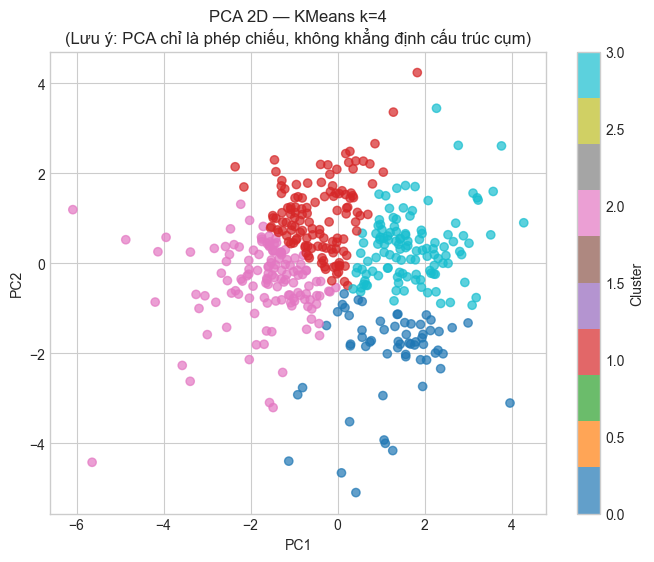

In [9]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)

from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=42).fit_transform(X_model)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels_km, cmap='tab10', alpha=0.7)
ax.set_title('PCA 2D — KMeans k=4\n(Lưu ý: PCA chỉ là phép chiếu, không khẳng định cấu trúc cụm)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.show()

## F. Visual hóa cụm (PCA 2D)

PCA fit trên `X_model` (6 chiều), chiếu về 2 trục chính để quan sát.

**PCA giúp quan sát:**
- Thấy được sự phân tách tương đối giữa các cụm trên 2 trục chính.
- Nhận diện điểm nào nằm gần centroid của cụm nào.
- Có cảm nhận trực quan về cấu trúc cụm (compact hay spread).

**PCA KHÔNG thể khẳng định:**
- Khoảng cách giữa 2 điểm trên biểu đồ là khoảng cách thực tế trong không gian 6 chiều.
- Cấu trúc cụm chính xác — có thể có overlap không hiển thị rõ trên 2D.
- Rằng 2 cụm "gần nhau" trên biểu đồ thực sự gần nhau trong không gian gốc.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,"1,073.00","6,964.00","10,518.00",340.00,"4,508.00",295.00
1,"17,023.00","3,086.00","3,445.00","4,324.00",529.00,"1,404.00"
2,"7,813.50","1,114.50","1,820.00","1,390.50",224.50,435.00
3,"7,832.50","8,481.50","12,271.50","1,347.00","4,643.50","1,681.50"


,HORECA (%),Retail (%)
cluster,,
0,34.40,65.60
1,94.60,5.40
2,99.20,0.80
3,20.30,79.70


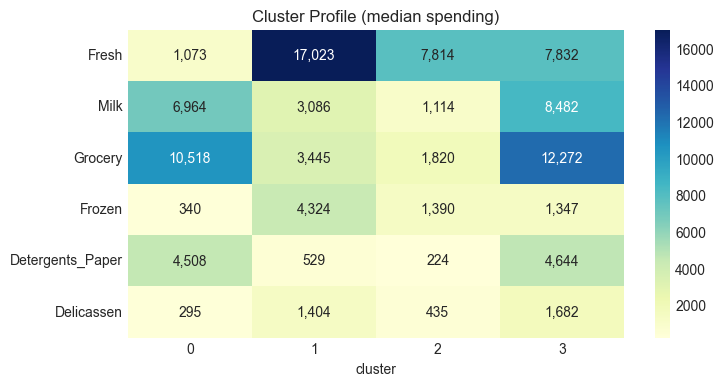

In [10]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()
import seaborn as sns

# Profile bằng median của X_raw
profile = X_raw.assign(cluster=labels_km).groupby('cluster').median()
display(profile)

# Thêm Channel breakdown
channel_breakdown = df[['Channel']].assign(cluster=labels_km)
channel_pct = channel_breakdown.groupby('cluster')['Channel'].value_counts(normalize=True).unstack(fill_value=0)
channel_pct = (channel_pct * 100).round(1)
channel_pct.columns = ['HORECA (%)', 'Retail (%)']
display(channel_pct)

# Heatmap profile
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(profile.T, annot=True, fmt=',.0f', cmap='YlGnBu', ax=ax)
ax.set_title('Cluster Profile (median spending)')
plt.show()



Quay về `X_raw` (đơn vị $). Profile bằng **median** — robust với outlier, phản ánh "khách hàng điển hình" tốt hơn mean.

### G.1 — Cluster Profile (median spending)

| Feature | Cụm 0 | Cụm 1 | Cụm 2 | Cụm 3 | Trung bình toàn bộ |
|---------|--------|--------|--------|--------|-------------------|
| Fresh | 1,073 | 17,023 | 7,814 | 7,833 | 8,504 |
| Milk | 6,964 | 3,086 | 1,115 | 8,482 | 3,627 |
| Grocery | 10,518 | 3,445 | 1,820 | 12,272 | 4,756 |
| Frozen | 340 | 4,324 | 1,391 | 1,347 | 1,526 |
| Detergents_Paper | 4,508 | 529 | 224 | 4,644 | 817 |
| Delicassen | 295 | 1,404 | 435 | 1,682 | 966 |
| Tổng | ~24,658 | ~29,811 | ~12,799 | ~36,260 | ~20,196 |

### G.2 — Đặt tên cụm

| Tên cụm | Label | Evidence |
|---------|-------|---------|
| **"Grocer & Detergent buyers"** | 0 | Grocery & Detergents cao nhất → pattern đi siêu thị mua tạp hóa. Channel: 40 Retail / 21 HO. |
| **"Fresh & Frozen specialists"** | 1 | Fresh & Frozen cao nhất → nhà hàng/quán ăn cần nguyên liệu tươi/đông lạnh. Channel: 122 HO / 7 Retail. |
| **"Low spenders"** | 2 | Tất cả feature thấp nhất → khách mua ít hoặc cửa hàng nhỏ. Channel: 131 HO / 1 Retail. |
| **"Big spenders"** | 3 | Grocery, Milk, Detergents, Frozen — gần như mọi danh mục đều cao. Channel: 94 Retail / 24 HO. |

### G.3 — Action Hypothesis

> **Hypothesis 1 (Cụm 0):** Các khách hàng này chi Grocery rất cao nhưng Milk thấp hơn → đề xuất gói **Milk upsell** (giảm giá Milk cho đơn hàng Grocery > 8000). Kiểm tra trong 4 tuần bằng A/B test.
>
> **Hypothesis 2 (Cụm 1):** HO customers chi Fresh & Frozen rất cao → đề xuất gói **bulk discount** cho đơn hàng Fresh đông lạnh. Đo xem có tăng tần suất đơn hàng không.
>
> **Hypothesis 3 (Cụm 3):** Big spenders chi mọi thứ — giàu tiềm năng nhất. Đề xuất **membership/loyalty program** để giữ chân.

### G.4 — Dữ liệu còn thiếu trước khi ra quyết định
- Biên lợi nhuận theo danh mục (chưa biết Grocery có margin tốt hơn Fresh không).
- Tần suất mua (hàng tuần hay hàng tháng) — ảnh hưởng đến frequency của campaign.
- Lịch sử phản hồi campaign trước đó.
- Chi phí logistics cho từng kênh (HO vs Retail).

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.


## H. Executive Summary

### 1. Khuyến nghị
**Thử nghiệm giới hạn** — không triển khai toàn bộ ngay. Clustering cho thấy có 4 nhóm hành vi chi tiêu khác biệt, nhưng silhouette = 0.188 cho thấy vùng overlap giữa các cụm. Nên test trên 1 nhóm cụm trước (Cụm 0 — Grocery & Detergent buyers) trước khi mở rộng.

### 2. Model / Preprocessing cuối
**KMeans k=4**, input = `log1p + StandardScaler`. Silhouette = 0.188, DB = 1.541, ARI stability (seed 42 vs 99) = 0.924 — ổn định cao, kết quả không phụ thuộc initialization.

### 3. Hai insight profile quan trọng nhất
1. **Cụm 0** (13.9%) chi Grocery + Detergents cao nhất trong khi Fresh thấp — đây là nhóm "siêu thị/gia đình lớn", tiềm năng upsell Milk và Delicassen.
2. **Cụm 1** (29.3%) là nhóm HO thuần túy (122/129 là Channel 1), chi Fresh + Frozen rất cao — phù hợp gói bulk discount cho nhà hàng/quán ăn.

### 4. Action thử trước và đánh giá
- **Action:** A/B test gửi voucher Milk 10% cho Cụm 0 khi mua Grocery > 8000$.
- **Đánh giá:** Đo conversion rate và tổng giá trị đơn hàng trong 4 tuần. So sánh với control group (không voucher).
- **KPI thành công:** Conversion rate > 25%, tổng GMV tăng > 15%.

### 5. Giới hạn quan trọng
- Silhouette thấp (0.188) → các cụm có overlap, cluster boundary không rõ ràng. Một số khách hàng có thể thuộc nửa cụm 0 nửa cụm 3.
- Thiếu data lợi nhuận, tần suất mua, chi phí logistics → chưa thể tính ROI chính xác hoặc tối ưu frequency của campaign.
- Chỉ dựa trên chi tiêu hằng năm — chưa có info về thời gian, xu hướng theo mùa, hoặc hành vi mua online/offline.



## Checklist trước khi nộp

- [x] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [x] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [x] Có ≥2 thuật toán và quyết định model có evidence.
- [x] Có kiểm tra stability/robustness và diễn giải kết quả.
- [x] Không đọc PCA 2D như bằng chứng duy nhất.
- [x] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [x] Có giới hạn và kết luận business rõ ràng.
